# Classificação de aptidão — milho 2ª safra, Mesorregião Oeste do Paraná

Este notebook aplica a metodologia de simulação + machine learning do `05_inferencias.ipynb` a
**50 municípios da Mesorregião Oeste Paranaense** (lista oficial do IBGE), para as mesmas 6 datas de
semeadura, e classifica cada combinação (município × data de semeadura) em dois eixos
independentes:

- **Risco climático** (seção 5): baseado no ISNA simulado, adaptado da lógica do ZARC.
- **Risco/viabilidade econômica** (seção 6): produtividade prevista × custo e preço reais da
  série histórica **SEAB/DERAL "Milho Safrinha"** (1999/00–2024/25) — não mais o pacote CONAB
  "Alta Tecnologia", que assumia produtividade (~6.260 kg/ha) incompatível com o que a água
  disponível nesses locais sustenta (o modelo prevê no máximo 4.543 kg/ha). Classificação
  **relativa** (tercis de margem), não um corte de aprovação/reprovação absoluto — ver seção 6
  para o porquê.

Os dois eixos se cruzam na seção 7 pra indicar a melhor data de semeadura por município.

## Diferenças em relação ao `05_inferencias.ipynb`

- **Cidades**: os 50 municípios do Oeste (mesorregião IBGE 4106), não só os 4 originais.
- **Anos**: 1999–2025 (27 anos) no eixo climático (simulação, estendido pra aproveitar toda a
  profundidade da série DERAL); 1999–2024 (26 anos) no eixo econômico (limitado pela série DERAL,
  que só vai até a safra 2024/25).
- **Clima**: buscado **uma vez por (município, ano)** e reaproveitado nas 6 datas de semeadura —
  o notebook original refaz a chamada à NASA POWER pra cada data (6× mais chamadas que o
  necessário, já que a mesma janela climática serve pra todas as datas daquele ano). A busca
  também é **incremental**: reaproveita o cache já processado e só roda os anos que faltam.
- **Sem validação contra `Yield_obs`**: essas cidades não têm produtividade observada na base
  usada pra validação do modelo — aqui o objetivo é aplicar o modelo (`ExtraTrees.joblib`, mesmo
  usado na etapa de aplicação do `05`), não validar.

In [1]:
import json
import time
import unicodedata
import urllib.request
from datetime import datetime, timedelta
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests

pd.set_option("display.width", 160)
plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3


def sem_acento(txt):
    return "".join(c for c in unicodedata.normalize("NFKD", str(txt)) if not unicodedata.combining(c)).upper()

/Users/coted-sh/Python/VS_CODE1/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## 1. Municípios da Mesorregião Oeste Paranaense

Lista oficial via API do IBGE (mesorregião 4106). Coordenadas, altitude e DTA do solo vêm de
`clima_solo_local.csv` (base nacional por município, já com os 50 municípios do Oeste cobertos).

In [2]:
URL_IBGE_MESORREGIAO = "https://servicodados.ibge.gov.br/api/v1/localidades/mesorregioes/4106/municipios"

resp = requests.get(URL_IBGE_MESORREGIAO, timeout=30)
resp.raise_for_status()
municipios_ibge = resp.json()

nomes_oeste = sorted(m["nome"] for m in municipios_ibge)
print(f"{len(nomes_oeste)} municípios na Mesorregião Oeste Paranaense (IBGE).")

solo = pd.read_csv("clima_solo_local.csv")
solo["norm"] = solo["Município"].apply(sem_acento)

nomes_oeste_norm = {sem_acento(n): n for n in nomes_oeste}
solo_oeste = solo[(solo["Estado"] == "PR") & (solo["norm"].isin(nomes_oeste_norm.keys()))].copy()

faltando = set(nomes_oeste_norm.keys()) - set(solo_oeste["norm"])
print(f"Municípios cobertos em clima_solo_local.csv: {len(solo_oeste)} / {len(nomes_oeste)}")
if faltando:
    print("ATENÇÃO — municípios sem dados de solo (serão excluídos):", [nomes_oeste_norm[f] for f in faltando])

municipios_alvo = solo_oeste[["Município", "Estado", "Altitude", "latitude", "longitude", "DTA (mm/m)"]].reset_index(drop=True)
municipios_alvo["DTA (mm/m)"] = (
    municipios_alvo["DTA (mm/m)"].astype(str).str.replace(",", ".", regex=False).astype(float)
)
municipios_alvo["Altitude"] = pd.to_numeric(municipios_alvo["Altitude"], errors="coerce")
municipios_alvo["latitude"] = pd.to_numeric(municipios_alvo["latitude"], errors="coerce")
municipios_alvo["longitude"] = pd.to_numeric(municipios_alvo["longitude"], errors="coerce")
municipios_alvo

50 municípios na Mesorregião Oeste Paranaense (IBGE).
Municípios cobertos em clima_solo_local.csv: 50 / 50


,Município,Estado,Altitude,latitude,longitude,DTA (mm/m)
0,Anahy,PR,445,-24.644181,-53.143821,130.4
1,Assis Chateaubriand,PR,388,-24.425925,-53.584571,109.8
2,Boa Vista da Aparecida,PR,402,-25.434815,-53.422326,107.2
3,Braganey,PR,559,-24.801423,-53.090476,129.2
4,Cafelândia,PR,578,-24.692457,-53.363957,110.8
5,Campo Bonito,PR,634,-24.931127,-53.013931,129.8
6,Capitão Leônidas Marques,PR,331,-25.470296,-53.592976,118.1
7,Cascavel,PR,661,-25.029371,-53.379713,118.1
8,Catanduvas,PR,631,-25.241718,-53.156039,134.9
9,Céu Azul,PR,487,-25.246265,-53.761784,124.8


## 2. Parâmetros da cultura (milho)

Fases fenológicas, coeficientes de cultura (Kc) e de resposta ao déficit hídrico (ky), do
repositório `agrometeorologia` (mesma fonte do `05_inferencias.ipynb`).

In [3]:
URL_DADOS_CULTURAS = "https://raw.githubusercontent.com/fcoliveira-utfpr/agrometeorologia/refs/heads/main/dados_culturas.csv"

dados_culturas = pd.read_csv(URL_DADOS_CULTURAS)
for c in dados_culturas.columns:
    if c != "Cultura":
        dados_culturas[c] = dados_culturas[c].astype(str).str.replace(",", ".", regex=False)
        dados_culturas[c] = pd.to_numeric(dados_culturas[c], errors="coerce")

milho_params = dados_culturas[dados_culturas["Cultura"] == "Milho"].iloc[0]
milho_params

Cultura          Milho
F1 %                17
F2 %                28
F3 %                33
F4 %                22
f                 0.55
Kc ini             0.3
Kc méd             1.2
Kc fin             0.6
Z efetivo (m)      0.4
ky1                0.4
ky2                1.5
ky3                0.5
ky4                0.2
Ky total          1.25
Name: 34, dtype: object

## 3. Simulação de balanço hídrico e produtividade atingível (Doorenbos-Kassam)

Mesma metodologia do `05_inferencias.ipynb` (Penman-Monteith, curva de Kc por fase, balanço de água
no solo, resposta de produtividade ao déficit hídrico por fase). Clima buscado uma vez por
(município, ano) e reaproveitado nas 6 datas de semeadura.

In [4]:
SEM = ["05/02/", "15/02/", "25/02/", "05/03/", "15/03/", "25/03/"]
ANOS = range(1999, 2026)  # bate com os 26 anos da série SEAB/DERAL (1999/00-2024/25) + 2025 pro eixo climático

DURACAO_CICLO = 100
CIAFMAX = 0.5
CC = (0.35 + 0.45) / 2
U = (10 + 13) / 2

FASE1, FASE2, FASE3, FASE4 = milho_params["F1 %"], milho_params["F2 %"], milho_params["F3 %"], milho_params["F4 %"]
KC1, KC2, KC3 = milho_params["Kc ini"], milho_params["Kc méd"], milho_params["Kc fin"]
KY1, KY2, KY3, KY4 = milho_params["ky1"], milho_params["ky2"], milho_params["ky3"], milho_params["ky4"]
Z_INICIAL = 0.05
Z_FINAL = milho_params["Z efetivo (m)"]

FASETOTAL = FASE1 + FASE2 + FASE3 + FASE4
FASE1D = (DURACAO_CICLO * FASE1) / FASETOTAL
FASE2D = (DURACAO_CICLO * FASE2) / FASETOTAL
FASE3D = (DURACAO_CICLO * FASE3) / FASETOTAL
FASE4D = (DURACAO_CICLO * FASE4) / FASETOTAL

ACRESCIMO_KC1 = (KC2 - KC1) / FASE2D
ACRESCIMO_KC2 = (KC3 - KC2) / FASE4D
ACRESCIMO_Z = (Z_FINAL - Z_INICIAL) / (FASE1D + FASE2D)


def dec_sol(nda):
    return 23.45 * np.sin(np.deg2rad(360 / 365 * (nda - 80)))


def hora_nascer_sol(d, lat):
    return np.rad2deg(np.arccos(-(np.tan(np.deg2rad(lat)) * np.tan(np.deg2rad(d)))))


def e_saturacao(temp):
    return 0.6108 * 10 ** ((7.5 * temp) / (237.3 + temp))


def bol(tmax, tmin, ea, qg, qgcs):
    a = 4.903e-9 * (((tmax + 273.16) ** 4 + (tmin + 273.16) ** 4) / 2)
    b = 0.34 - 0.14 * np.sqrt(ea)
    c = 1.35 * (qg / qgcs) - 0.35
    return -(a * b * c)


def eto_penman(s, rn, gama, u2, es, ea, tmed):
    eto1 = 0.408 * s * rn
    eto2 = (gama * 900 * u2 * (es - ea)) / (tmed + 273)
    eto3 = s + gama * (1 + 0.34 * u2)
    return (eto1 + eto2) / eto3


def buscar_clima_diario(latitude, longitude, ano_inicial):
    ano_final = ano_inicial + 1
    ini = int(datetime(ano_inicial, 1, 1).strftime("%Y%m%d"))
    fim = int(datetime(ano_final, 12, 31).strftime("%Y%m%d"))

    base_url = (
        "https://power.larc.nasa.gov/api/temporal/daily/point"
        "?parameters=T2M_MIN,T2M_MAX,PRECTOTCORR,RH2M,WS2M,ALLSKY_SFC_SW_DWN,TOA_SW_DWN"
        "&community=RE&longitude={lon}&latitude={lat}&start={ini}&end={fim}&format=JSON"
    )
    resp = requests.get(base_url.format(lon=longitude, lat=latitude, ini=ini, fim=fim), timeout=120)
    resp.raise_for_status()
    parametros = resp.json()["properties"]["parameter"]

    datas_str = sorted(parametros["T2M_MIN"].keys())
    datas = [pd.to_datetime(d) for d in datas_str]

    df = pd.DataFrame({"Data": datas})
    df["Tmin"] = [parametros["T2M_MIN"][d] for d in datas_str]
    df["Tmax"] = [parametros["T2M_MAX"][d] for d in datas_str]
    df["Chuva"] = [parametros["PRECTOTCORR"][d] for d in datas_str]
    df["UR"] = [parametros["RH2M"][d] for d in datas_str]
    df["U2"] = [parametros["WS2M"][d] for d in datas_str]
    df["Rs"] = np.array([parametros["ALLSKY_SFC_SW_DWN"][d] for d in datas_str]) * 3.6
    df["Qo"] = np.array([parametros["TOA_SW_DWN"][d] for d in datas_str]) * 3.6

    df["Tmed"] = (df["Tmax"] + df["Tmin"]) / 2
    df["Patm"] = 101.3 * ((293 - 0.0065 * alt_atual) / 293) ** 5.26
    df["NDA"] = df["Data"].dt.dayofyear

    df["d"] = df["NDA"].apply(dec_sol)
    df["Hn"] = df["d"].apply(lambda d_: hora_nascer_sol(d_, latitude))
    df["BOC"] = df["Rs"] * 0.75
    df["N"] = (2 * df["Hn"]) / 15
    df["n_inso"] = (((df["Rs"] / df["Qo"]) - (0.29 * np.cos(latitude))) / 0.52) * df["N"]

    df["es_Tmax"] = df["Tmax"].apply(e_saturacao)
    df["es_Tmin"] = df["Tmin"].apply(e_saturacao)
    df["es"] = (df["es_Tmax"] + df["es_Tmin"]) / 2
    df["ea"] = (df["UR"] / 100) * df["es"]
    df["QGcs"] = df["Qo"] * (0.75 + (2e-5) * alt_atual)

    df["BOL"] = bol(df["Tmax"], df["Tmin"], df["ea"], df["Rs"], df["QGcs"])
    df["Rn"] = df["BOC"] + df["BOL"]
    df["s"] = (4098 * df["es"]) / (df["Tmed"] + 237.3) ** 2
    df["gama"] = 0.665e-3 * df["Patm"]
    df["ETo"] = eto_penman(df["s"], df["Rn"], df["gama"], df["U2"], df["es"], df["ea"], df["Tmed"])

    df.replace(-999, np.nan, inplace=True)
    df.interpolate(inplace=True)
    return df

In [5]:
def simular_safra(clima, dta, data_sem_str, ano_inicial):
    data_semeadura = datetime.strptime(f"{data_sem_str}{ano_inicial}", "%d/%m/%Y")
    data_maturacao = data_semeadura + timedelta(days=DURACAO_CICLO - 1)

    safra1 = clima.loc[(clima["Data"] >= data_semeadura) & (clima["Data"] <= data_maturacao)].copy()
    if len(safra1) < DURACAO_CICLO:
        return None
    safra1["n"] = range(1, len(safra1) + 1)

    fase_cultura, kc_lista = [], []
    for n in safra1["n"]:
        if n <= FASE1D:
            kc_lista.append(KC1); fase_cultura.append(1)
        elif n <= FASE1D + FASE2D:
            kc_lista.append(kc_lista[-1] + ACRESCIMO_KC1); fase_cultura.append(2)
        elif n <= FASE1D + FASE2D + FASE3D:
            kc_lista.append(KC2); fase_cultura.append(3)
        else:
            kc_lista.append(kc_lista[-1] + ACRESCIMO_KC2); fase_cultura.append(4)
    safra1["Kc"] = kc_lista
    safra1["Fase"] = fase_cultura

    z1 = []
    for n in safra1["n"]:
        if n == 1:
            z1.append(Z_INICIAL + ACRESCIMO_Z)
        elif n <= FASE1D + FASE2D:
            z1.append(z1[-1] + ACRESCIMO_Z)
        else:
            z1.append(Z_FINAL)
    safra1["z"] = z1

    safra1["CAD"] = safra1["z"] * dta
    safra1["ETc"] = safra1["Kc"] * safra1["ETo"]
    safra1["P-ETc"] = safra1["Chuva"] - safra1["ETc"]

    petc = safra1["P-ETc"].to_numpy()
    cad = safra1["CAD"].to_numpy()
    arm = [Z_INICIAL * dta]
    for p, c in zip(petc, cad):
        prev = arm[-1]
        if p < 0:
            arm.append(prev * np.exp(p / c))
        elif p + prev >= c:
            arm.append(c)
        else:
            arm.append(prev + p)
    arm = arm[1:]
    safra1["ARM"] = arm

    alt = [0] + list(np.array(arm[1:]) - np.array(arm[:-1]))
    safra1["ALT"] = alt

    safra1["ETR"] = np.where(safra1["P-ETc"] < 0, safra1["Chuva"] + np.abs(safra1["ALT"]), safra1["ETc"])
    safra1["DEF"] = safra1["ETc"] - safra1["ETR"]
    safra1["EXC"] = np.where(safra1["ARM"] < safra1["CAD"], 0, safra1["P-ETc"] - safra1["ALT"])
    safra1["ISNA_diario"] = safra1["ETR"] / safra1["ETc"]

    safra1["n/N"] = safra1["n_inso"] / safra1["N"]
    safra1["qo"] = safra1["Qo"] * 23.9234
    safra1["cTc"] = -4.16 + (0.4325 * safra1["Tmed"]) - (0.00725 * safra1["Tmed"] ** 2)
    safra1["cTn"] = -1.064 + (0.173 * safra1["Tmed"]) + (0.0029 * safra1["Tmed"] ** 2)
    safra1["PPBp"] = (
        (107.2 + 0.36 * safra1["qo"]) * safra1["cTc"] * safra1["n/N"]
        + (31.7 + 0.219 * safra1["qo"]) * safra1["cTn"] * (1 - safra1["n/N"])
    )
    safra1["CR"] = np.where(safra1["Tmed"] >= 20, 0.5, 0.6)
    safra1["PP"] = (safra1["PPBp"] * CIAFMAX * safra1["CR"] * CC) / (1 - 0.01 * U)

    bp = safra1["PP"].sum()

    def rc_fase(a, b):
        return safra1["ETR"].iloc[a:b].sum() / safra1["ETc"].iloc[a:b].sum()

    rc_1 = rc_fase(0, int(FASE1D))
    rc_2 = rc_fase(int(FASE1D), int(FASE1D + FASE2D))
    rc_3 = rc_fase(int(FASE1D + FASE2D), int(FASE1D + FASE2D + FASE3D))
    rc_4 = rc_fase(int(FASE1D + FASE2D + FASE3D), int(FASE1D + FASE2D + FASE3D + FASE4D))

    pa1 = (1 - KY1 * (1 - rc_1)) * bp
    pa2 = (1 - KY2 * (1 - rc_2)) * pa1
    pa3 = (1 - KY3 * (1 - rc_3)) * pa2
    pa4 = (1 - KY4 * (1 - rc_4)) * pa3

    safra = safra1.groupby("Fase").agg(
        Tmin=("Tmin", "mean"), Tmax=("Tmax", "mean"), Tmed=("Tmed", "mean"),
        Chuva=("Chuva", "sum"), UR=("UR", "mean"), ETc=("ETc", "sum"), ETR=("ETR", "sum"),
        ARM=("ARM", "last"), DEF=("DEF", "sum"), EXC=("EXC", "sum"), N=("N", "mean"), PP=("PP", "sum"),
    ).reset_index()
    safra["ISNA"] = [rc_1, rc_2, rc_3, rc_4]
    safra["PA"] = [pa1, pa2, pa3, pa4]
    safra["Data semeadura"] = data_semeadura
    safra["Data maturação"] = data_maturacao
    return safra

### Rodar a simulação — 50 municípios × 27 anos × 6 datas de semeadura

Busca clima uma vez por (município, ano) — até 50 × 27 = 1.350 combinações — e simula as 6 datas
de semeadura a partir dela. **Reaproveita o cache existente** (`df_wide_oeste.csv`, já tinha
2019–2025) e roda só as combinações (município, ano) que ainda faltam — no caso, 1999–2018. Falhas
pontuais (timeout, município sem dado num ano) são registradas e puladas, sem interromper o
restante.

In [6]:
CACHE_DF_WIDE_OESTE = Path("df_wide_oeste.csv")

if CACHE_DF_WIDE_OESTE.exists():
    df_wide_cache = pd.read_csv(CACHE_DF_WIDE_OESTE)
    combos_existentes = set(zip(df_wide_cache["Municipio"], df_wide_cache["Ano"]))
    print(f"Cache existente: {len(combos_existentes)} combinações (município, ano) já processadas.")
else:
    df_wide_cache = pd.DataFrame()
    combos_existentes = set()

combos_faltando = [
    (row["Município"], ano)
    for _, row in municipios_alvo.iterrows()
    for ano in ANOS
    if (row["Município"], ano) not in combos_existentes
]
print(f"Combinações faltando: {len(combos_faltando)}")

if combos_faltando:
    municipios_por_nome = municipios_alvo.set_index("Município")
    registros = []
    falhas = []
    contador = 0

    for municipio, ano_inicial in combos_faltando:
        contador += 1
        row = municipios_por_nome.loc[municipio]
        lat, lon, alt_atual, dta = row["latitude"], row["longitude"], row["Altitude"], row["DTA (mm/m)"]

        try:
            clima = buscar_clima_diario(lat, lon, ano_inicial)
        except Exception as exc:
            falhas.append({"municipio": municipio, "ano": ano_inicial, "etapa": "clima", "erro": str(exc)})
            continue

        for data_sem in SEM:
            try:
                safra = simular_safra(clima, dta, data_sem, ano_inicial)
                if safra is None:
                    falhas.append({"municipio": municipio, "ano": ano_inicial, "etapa": f"safra {data_sem}", "erro": "dados insuficientes"})
                    continue
                safra["Municipio"] = municipio
                safra["Ano"] = ano_inicial
                safra["Latitude"] = lat
                safra["Longitude"] = lon
                safra["Altitude"] = alt_atual
                registros.append(safra)
            except Exception as exc:
                falhas.append({"municipio": municipio, "ano": ano_inicial, "etapa": f"safra {data_sem}", "erro": str(exc)})

        if contador % 25 == 0:
            print(f"{contador}/{len(combos_faltando)} (município, ano) novos processados...")

    if falhas:
        pd.DataFrame(falhas).to_csv("falhas_simulacao_09.csv", index=False, encoding="utf-8-sig")
        print(f"\n{len(falhas)} falhas salvas em falhas_simulacao_09.csv")

    if registros:
        df_simulado_novo = pd.concat(registros, ignore_index=True)
        print(f"Simulação nova concluída: {df_simulado_novo.shape[0]} linhas (fase).")

        df = df_simulado_novo.copy()
        df["Amp"] = df["Tmax"] - df["Tmin"]
        df["Pefetiva"] = df["Chuva"] / df["ETc"]
        df["T_DEF"] = df["Tmax"] * df["DEF"]

        df["Data semeadura"] = pd.to_datetime(df["Data semeadura"])
        df["Data maturação"] = pd.to_datetime(df["Data maturação"])
        df["DOY_semeadura"] = df["Data semeadura"].dt.dayofyear
        df["DOY_maturacao"] = df["Data maturação"].dt.dayofyear
        df["lat_lon"] = df["Latitude"] * df["Longitude"]
        df = df.drop(columns=["Data semeadura", "Data maturação"])

        vars_fase = [
            "Tmin", "Tmax", "Tmed", "Chuva", "UR", "ETc", "ETR", "ARM", "DEF", "EXC",
            "ISNA", "PA", "Amp", "Pefetiva", "Latitude", "Longitude", "Altitude", "T_DEF", "lat_lon",
        ]

        df["rep"] = df.groupby(["Municipio", "Ano", "DOY_semeadura", "DOY_maturacao", "Fase"]).cumcount()

        df_wide_novo = df.pivot(
            index=["Municipio", "Ano", "DOY_semeadura", "DOY_maturacao", "rep"], columns="Fase", values=vars_fase
        )
        df_wide_novo.columns = [f"{v}_F{f}" for v, f in df_wide_novo.columns]
        df_wide_novo = df_wide_novo.reset_index()

        df_wide_novo = df_wide_novo.drop(
            columns=[c for c in df_wide_novo.columns if c.split("_F")[-1] in ("2", "3", "4") and c.split("_F")[0] in ("Altitude", "Latitude", "Longitude", "lat_lon")],
            errors="ignore",
        )

        df_wide_oeste = pd.concat([df_wide_cache, df_wide_novo], ignore_index=True)
    else:
        df_wide_oeste = df_wide_cache

    df_wide_oeste.to_csv(CACHE_DF_WIDE_OESTE, index=False, encoding="utf-8-sig")
else:
    print("Cache já cobre todos os anos pedidos — nada a rodar.")
    df_wide_oeste = df_wide_cache

print(df_wide_oeste.shape)
df_wide_oeste.head()

Cache existente: 1350 combinações (município, ano) já processadas.
Combinações faltando: 0
Cache já cobre todos os anos pedidos — nada a rodar.
(8100, 69)


,Municipio,Ano,DOY_semeadura,DOY_maturacao,rep,Tmin_F1,Tmin_F2,Tmin_F3,Tmin_F4,Tmax_F1,...,Pefetiva_F3,Pefetiva_F4,Latitude_F1,Longitude_F1,Altitude_F1,T_DEF_F1,T_DEF_F2,T_DEF_F3,T_DEF_F4,lat_lon_F1
0,Anahy,2019,36,135,0,20.161176,20.273214,18.016970,17.801364,30.016471,...,0.317540,2.322369,-24.644181,-53.143821,445.0,72.440981,179.784865,1610.893573,283.435068,1309.685953
1,Anahy,2019,46,145,0,18.922353,19.924643,18.170303,15.621818,29.135882,...,0.772594,2.676810,-24.644181,-53.143821,445.0,38.434651,600.111248,1387.571247,122.540312,1309.685953
2,Anahy,2019,56,155,0,19.824118,19.024286,18.162727,13.974091,29.367647,...,1.145028,5.611903,-24.644181,-53.143821,445.0,120.494164,667.276794,1146.885054,67.170302,1309.685953
3,Anahy,2019,64,163,0,21.228824,17.871786,17.229091,13.092727,28.460588,...,1.261495,6.123772,-24.644181,-53.143821,445.0,41.482800,887.625842,650.882766,41.250394,1309.685953
4,Anahy,2019,74,173,0,19.075882,18.332857,15.925455,12.937727,28.534118,...,3.153234,0.507958,-24.644181,-53.143821,445.0,167.982964,676.843871,213.214079,201.991366,1309.685953


## 4. Previsão (ExtraTrees)

Mesmo modelo usado na etapa de aplicação do `05_inferencias.ipynb` (sem o merge com `Yield_obs`, que
não existe pra estas cidades).

In [7]:
modelo_et = joblib.load("ExtraTrees.joblib")

FEATURES = ['UR_F1', 'T_DEF_F1', 'DEF_F1', 'Tmax_F1', 'Tmed_F2', 'Tmed_F1',
       'Tmax_F2', 'UR_F2', 'ISNA_F1', 'Tmin_F2', 'Tmin_F3', 'T_DEF_F2',
       'ETc_F1', 'DEF_F2', 'Altitude_F1', 'Amp_F4', 'Tmin_F1', 'Pefetiva_F1',
       'PA_F2', 'Tmed_F3', 'Chuva_F1', 'Tmin_F4', 'ISNA_F2', 'PA_F3', 'EXC_F1',
       'Longitude_F1', 'PA_F4', 'Amp_F3', 'Chuva_F2', 'ARM_F1', 'ETR_F4',
       'EXC_F2', 'ETR_F2', 'Pefetiva_F2', 'ARM_F3', 'Tmed_F4', 'ARM_F2',
       'Tmax_F3', 'ETc_F2', 'ETR_F1', 'Amp_F1', 'Latitude_F1', 'ETR_F3',
       'UR_F4', 'T_DEF_F4', 'DEF_F4', 'ISNA_F3', 'Pefetiva_F4', 'ISNA_F4',
       'UR_F3', 'Tmax_F4', 'lat_lon_F1', 'EXC_F3', 'ETc_F3', 'ETc_F4', 'PA_F1',
       'Chuva_F3', 'ARM_F4', 'DEF_F3', 'Chuva_F4', 'Amp_F2', 'EXC_F4',
       'Pefetiva_F3', 'T_DEF_F3', 'DOY_semeadura', 'DOY_maturacao']

X = df_wide_oeste[FEATURES]
df_wide_oeste["produtividade_prevista_kg_ha"] = modelo_et.predict(X)

def doy_para_data_sem(ano, doy):
    # Recalcula a partir do dia-do-ano real (bissexto desloca datas de março em +1 dia)
    data = datetime(int(ano), 1, 1) + timedelta(days=int(doy) - 1)
    return f"{data.day:02d}/{data.month:02d}/"


df_wide_oeste["data_semeadura"] = df_wide_oeste.apply(
    lambda r: doy_para_data_sem(r["Ano"], r["DOY_semeadura"]), axis=1
)
nao_reconhecidas = ~df_wide_oeste["data_semeadura"].isin(SEM)
if nao_reconhecidas.any():
    print(f"ATENÇÃO — {nao_reconhecidas.sum()} linhas com data de semeadura fora do esperado, descartadas.")
    df_wide_oeste = df_wide_oeste[~nao_reconhecidas].copy()

previsoes = df_wide_oeste[["Municipio", "Ano", "data_semeadura", "produtividade_prevista_kg_ha"]].rename(
    columns={"Municipio": "municipio", "Ano": "ano"}
)
previsoes.to_csv("previsoes_oeste_pr.csv", index=False, encoding="utf-8-sig")
print(previsoes.shape)
previsoes.head(12)

(8100, 4)


,municipio,ano,data_semeadura,produtividade_prevista_kg_ha
0,Anahy,2019,05/02/,2940.726180
1,Anahy,2019,15/02/,3133.112355
2,Anahy,2019,25/02/,2875.978996
3,Anahy,2019,05/03/,2661.706569
4,Anahy,2019,15/03/,2665.089129
5,Anahy,2019,25/03/,2434.100158
6,Anahy,2020,05/02/,4033.568155
7,Anahy,2020,15/02/,3751.372258
8,Anahy,2020,25/02/,3907.237043
9,Anahy,2020,05/03/,4084.913139


## 5. Risco climático (ISNA — adaptado do Zoneamento Agrícola de Risco Climático)

A primeira tentativa de classificação (comparando produtividade prevista com o custo/preço real
ano a ano) misturava risco climático com risco de mercado — e o ciclo de mercado (custo alto/preço
baixo em 2022–2025, o oposto em 2020–2021) dominou completamente a variação climática entre
cidades: em todo ano, a margem tinha o mesmo sinal para as 300 combinações, mesmo com produtividade
variando bastante entre elas. Ou seja, a regra não conseguia diferenciar cidade nem data de
semeadura.

Por isso, separamos em dois eixos independentes. Este primeiro é **puramente climático/agronômico**,
sem nenhuma variável de custo ou preço — a mesma lógica usada pelo **Zoneamento Agrícola de Risco
Climático (ZARC)** do MAPA/Embrapa para indicar época de semeadura: usa o **ISNA** (Índice de
Satisfação da Necessidade de Água, `ETR/ETc`) que a simulação já calcula por fase.

Como o milho é mais sensível ao déficit hídrico em certas fases (o `ky` de cada fase mede essa
sensibilidade — floração/fase 2 é a mais crítica, `ky2 = 1,5`), calculamos um **ISNA geral
ponderado pelos `ky` de cada fase**, e classificamos cada (município, data de semeadura) pela
**média do ISNA geral nos 7 anos simulados**:

- **Baixo risco climático**: ISNA médio ≥ 0,65.
- **Médio risco climático**: 0,50 ≤ ISNA médio < 0,65.
- **Alto risco climático**: ISNA médio < 0,50.

*(Esses limiares são uma adaptação ilustrativa da lógica do ZARC — não são os valores exatos de
uma portaria oficial do MAPA para o milho; se precisar de conformidade formal com o ZARC, os
limiares oficiais por cultura/UF precisam ser conferidos diretamente nas portarias.)*

In [8]:
df_wide_oeste["ISNA_geral"] = (
    KY1 * df_wide_oeste["ISNA_F1"] + KY2 * df_wide_oeste["ISNA_F2"]
    + KY3 * df_wide_oeste["ISNA_F3"] + KY4 * df_wide_oeste["ISNA_F4"]
) / (KY1 + KY2 + KY3 + KY4)

isna_cidade_data = (
    df_wide_oeste.groupby(["Municipio", "data_semeadura"])["ISNA_geral"]
    .agg(isna_medio="mean", isna_desvio="std", n_anos="count")
    .reset_index()
    .rename(columns={"Municipio": "municipio"})
)


def classificar_clima(isna):
    if isna >= 0.65:
        return "Baixo risco climático"
    if isna >= 0.50:
        return "Médio risco climático"
    return "Alto risco climático"


isna_cidade_data["risco_climatico"] = isna_cidade_data["isna_medio"].apply(classificar_clima)
isna_cidade_data.to_csv("risco_climatico_oeste_pr.csv", index=False, encoding="utf-8-sig")

print(isna_cidade_data["risco_climatico"].value_counts())
isna_cidade_data.sort_values("isna_medio", ascending=False).head(15)

risco_climatico
Baixo risco climático    296
Médio risco climático      4
Name: count, dtype: int64


,municipio,data_semeadura,isna_medio,isna_desvio,n_anos,risco_climatico
72,Diamante do Sul,05/02/,0.786501,0.098661,27,Baixo risco climático
96,Guaraniaçu,05/02/,0.780250,0.101995,27,Baixo risco climático
48,Catanduvas,05/02/,0.778491,0.101650,27,Baixo risco climático
18,Braganey,05/02/,0.775017,0.102059,27,Baixo risco climático
108,Ibema,05/02/,0.774810,0.101768,27,Baixo risco climático
30,Campo Bonito,05/02/,0.774672,0.102205,27,Baixo risco climático
74,Diamante do Sul,15/02/,0.773392,0.090653,27,Baixo risco climático
42,Cascavel,05/02/,0.769379,0.101617,27,Baixo risco climático
98,Guaraniaçu,15/02/,0.769103,0.091536,27,Baixo risco climático
50,Catanduvas,15/02/,0.767835,0.091323,27,Baixo risco climático


## 6. Risco econômico (referência SEAB/DERAL — milho safrinha)

A primeira versão deste eixo usava o custo de referência da CONAB (notebook `07`, cidades Assis
Chateaubriand/Francisco Beltrão/M. Cândido Rondon) — mas esse pacote é **"Agricultura Empresarial
— Alta Tecnologia — OGM"**, calibrado pra uma produtividade (~6.260 kg/ha) bem mais alta do que
qualquer cenário simulado atinge (máximo 4.543 kg/ha). Isso forçava toda a classificação pra
"Inapta"/"menos viável" de forma quase uniforme.

Encontramos uma fonte melhor: a planilha **SEAB/DERAL "Estimativa de Custos de Produção — Milho
Safrinha"** (`nhistorico_94.xls`, aba `milho_saf`) traz uma **série histórica de 26 safras
(1999/00–2024/25)**, em R$/saca de 60kg, com a produtividade de referência documentada por época
(**60–80 sc/ha = 3.600–4.800 kg/ha**) — muito mais compatível com o que o modelo prevê.

Como a série de preço (IPEA/SEAB-Deral) também cobre desde 1990, e a simulação climática agora
roda **1999–2025** (estendida especificamente pra aproveitar essa profundidade — ver seção 3),
a comparação ano a ano passa a ter **26 anos em comum** (1999–2024, limitado pelo fim da série
DERAL) em vez de só 6 — uma base estatística bem mais robusta pro "% de anos que cobre o custo".

Reaplicamos a decomposição fixo/variável de antes, mas agora com os números do DERAL, e
**comparando ano a ano** (não uma média fixa) — com a escala compatível, a variação real entre
anos passa a diferenciar os municípios de verdade (ex.: em 2020, a margem variou de –R$356 a
+R$255/ha só pela diferença de produtividade prevista entre eles).

In [9]:
df_deral = pd.read_excel("nhistorico_94.xls", sheet_name="milho_saf", header=None)
dados_deral = df_deral.iloc[7:33, [0, 2, 3]].copy()
dados_deral.columns = ["safra", "custo_60kg_variavel_nominal", "custo_60kg_total_nominal"]
dados_deral["ano"] = dados_deral["safra"].str.slice(0, 4).astype(int)


def produtividade_sc_ha(ano):
    if ano <= 2003:
        return 60
    if ano <= 2005:
        return 80
    if ano == 2006:
        return 75
    if ano <= 2014:
        return 70
    return 80


dados_deral["produtividade_kg_ha"] = dados_deral["ano"].apply(produtividade_sc_ha) * 60
dados_deral["custo_rs_ha_total_nominal"] = dados_deral["custo_60kg_total_nominal"] * dados_deral["produtividade_kg_ha"] / 60
dados_deral["custo_rs_ha_variavel_nominal"] = dados_deral["custo_60kg_variavel_nominal"] * dados_deral["produtividade_kg_ha"] / 60

ipca_anual_full = pd.read_csv("ipca_anual.csv")
indice_base_2025 = ipca_anual_full.loc[ipca_anual_full["ano"] == 2025, "indice_medio"].iloc[0]
ipca_anual_full["fator_deflator"] = indice_base_2025 / ipca_anual_full["indice_medio"]

dados_deral = dados_deral.merge(ipca_anual_full[["ano", "fator_deflator"]], on="ano", how="left")
dados_deral["custo_rs_ha_total_real"] = dados_deral["custo_rs_ha_total_nominal"] * dados_deral["fator_deflator"]
dados_deral["custo_rs_ha_variavel_real"] = dados_deral["custo_rs_ha_variavel_nominal"] * dados_deral["fator_deflator"]
dados_deral["custo_fixo_real"] = dados_deral["custo_rs_ha_total_real"] - dados_deral["custo_rs_ha_variavel_real"]
dados_deral["custo_var_kg_real"] = dados_deral["custo_rs_ha_variavel_real"] / dados_deral["produtividade_kg_ha"]

dados_deral.to_csv("custo_deral_milho_safrinha.csv", index=False, encoding="utf-8-sig")
dados_deral[["ano", "produtividade_kg_ha", "custo_rs_ha_total_real", "custo_fixo_real", "custo_var_kg_real"]].tail(8).round(2)

,ano,produtividade_kg_ha,custo_rs_ha_total_real,custo_fixo_real,custo_var_kg_real
18,2017,4800,4541.624945,1902.181907,0.549884
19,2018,4800,4610.004191,2012.736894,0.541097
20,2019,4800,4816.033045,2084.819143,0.569003
21,2020,4800,4748.665712,2016.69049,0.569162
22,2021,4800,5037.107943,2207.868842,0.589425
23,2022,4800,6969.986424,3004.43099,0.826157
24,2023,4800,6485.883424,2797.952414,0.768319
25,2024,4800,5907.822556,2779.163398,0.651804


In [10]:
preco_ref_full = pd.read_csv("precos_milho_pr.csv")
ANOS_EM_COMUM = [a for a in range(1999, 2026) if a in dados_deral["ano"].values and a in preco_ref_full["ano"].values]
print(f"Anos em comum entre simulação, custo DERAL e preço: {len(ANOS_EM_COMUM)} ({min(ANOS_EM_COMUM)}-{max(ANOS_EM_COMUM)})")

deral_idx = dados_deral.set_index("ano")
preco_idx = preco_ref_full.set_index("ano")["preco_rs_60kg_real"]


def calcular_risco_economico(fator_rateio_custo_fixo, rotulo):
    base = previsoes[previsoes["ano"].isin(ANOS_EM_COMUM)].copy()
    base["custo_fixo"] = base["ano"].map(deral_idx["custo_fixo_real"]) * fator_rateio_custo_fixo
    base["custo_var_kg"] = base["ano"].map(deral_idx["custo_var_kg_real"])
    base["preco_60kg"] = base["ano"].map(preco_idx)

    base["custo_ajustado_rs_ha"] = base["custo_fixo"] + base["custo_var_kg"] * base["produtividade_prevista_kg_ha"]
    base["receita_rs_ha"] = (base["preco_60kg"] / 60) * base["produtividade_prevista_kg_ha"]
    base["margem_rs_ha"] = base["receita_rs_ha"] - base["custo_ajustado_rs_ha"]
    base["cobre_custo"] = base["margem_rs_ha"] >= 0

    risco = base.groupby(["municipio", "data_semeadura"]).agg(
        n_anos=("ano", "count"),
        pct_anos_cobre_custo=("cobre_custo", "mean"),
        margem_media_rs_ha=("margem_rs_ha", "mean"),
    ).reset_index()
    risco["pct_anos_cobre_custo"] = (risco["pct_anos_cobre_custo"] * 100).round(1)
    risco["risco_economico"] = pd.qcut(
        risco["margem_media_rs_ha"],
        q=3,
        labels=["Menos viável", "Viabilidade intermediária", "Mais viável"],
    )

    print(f"\n[{rotulo}] % de combinações (município×data) que cobrem o custo, por ano:")
    print((base.groupby("ano")["cobre_custo"].mean() * 100).round(1))
    print(f"\n[{rotulo}] distribuição de risco_economico:")
    print(risco["risco_economico"].value_counts())

    return risco


# Cenário principal (mantido igual ao original): 100% do custo fixo, como se o milho safrinha
# arcasse sozinho com terra/máquina/depreciação — é o que segue alimentando as seções 7-8 e o
# notebook 10.
risco_economico = calcular_risco_economico(1.0, "Custo Total (100% do custo fixo)")
risco_economico.to_csv("risco_economico_oeste_pr.csv", index=False, encoding="utf-8-sig")

risco_economico.sort_values("margem_media_rs_ha", ascending=False).head(15)

Anos em comum entre simulação, custo DERAL e preço: 26 (1999-2024)

[Custo Total (100% do custo fixo)] % de combinações (município×data) que cobrem o custo, por ano:
ano
1999      0.0
2000      0.0
2001      0.0
2002      0.0
2003      0.0
2004      0.0
2005      0.0
2006      0.0
2007      0.0
2008      0.0
2009      0.0
2010      0.0
2011      0.0
2012      0.0
2013      0.0
2014      0.0
2015      0.0
2016      0.0
2017      0.0
2018      0.0
2019      0.0
2020     52.3
2021    100.0
2022      0.0
2023      0.0
2024      0.0
Name: cobre_custo, dtype: float64

[Custo Total (100% do custo fixo)] distribuição de risco_economico:
risco_economico
Menos viável                 100
Viabilidade intermediária    100
Mais viável                  100
Name: count, dtype: int64


,municipio,data_semeadura,n_anos,pct_anos_cobre_custo,margem_media_rs_ha,risco_economico
52,Catanduvas,25/02/,26,7.7,-822.618901,Mais viável
112,Ibema,25/02/,26,7.7,-823.251696,Mais viável
74,Diamante do Sul,15/02/,26,3.8,-825.252747,Mais viável
46,Cascavel,25/02/,26,7.7,-825.539941,Mais viável
100,Guaraniaçu,25/02/,26,7.7,-825.756108,Mais viável
49,Catanduvas,05/03/,26,3.8,-828.538975,Mais viável
34,Campo Bonito,25/02/,26,7.7,-829.419171,Mais viável
76,Diamante do Sul,25/02/,26,3.8,-829.711142,Mais viável
50,Catanduvas,15/02/,26,7.7,-830.073739,Mais viável
98,Guaraniaçu,15/02/,26,7.7,-830.536766,Mais viável


### 6.1 Sensibilidade: rateio do custo fixo entre culturas em sucessão

O cenário acima (seção 6) atribui **100% do custo fixo** (terra, depreciação de máquinas,
administração — ver `custo_fixo_real` no DERAL) ao milho safrinha, como se ele fosse plantado
isoladamente. Mas na prática o milho safrinha **sucede a soja** no mesmo ano-agrícola, na mesma
área e com a mesma máquina — parte desse custo fixo já é amortizada pela cultura principal (soja).
Atribuir 100% dele ao safrinha superestima o custo real da decisão marginal de plantar (ou não) a
segunda safra.

Como referência de sensibilidade, a célula abaixo recalcula o mesmo eixo econômico com um
**rateio de 50%** do custo fixo (`fator_rateio_custo_fixo = 0.5`) — não substitui o cenário
principal (que continua alimentando as seções 7-8), serve para comparar o quanto a classificação de
viabilidade econômica é sensível a essa premissa.


[Rateio 50% do custo fixo (sucessão soja→milho)] % de combinações (município×data) que cobrem o custo, por ano:
ano
1999    100.0
2000    100.0
2001      0.0
2002     99.7
2003    100.0
2004     89.3
2005      1.7
2006     19.7
2007    100.0
2008     94.7
2009      0.0
2010      0.0
2011    100.0
2012      0.0
2013      0.0
2014      0.0
2015      0.0
2016     35.3
2017      0.0
2018      0.0
2019      0.0
2020    100.0
2021    100.0
2022    100.0
2023     99.7
2024      0.0
Name: cobre_custo, dtype: float64

[Rateio 50% do custo fixo (sucessão soja→milho)] distribuição de risco_economico:
risco_economico
Menos viável                 100
Viabilidade intermediária    100
Mais viável                  100
Name: count, dtype: int64


Município×data que mudam de classificação de risco econômico com o rateio de 50%: 0/300
risco_economico_100pct     risco_economico_rateio50 
Menos viável               Menos viável                 100
Viabilidade intermediária  Viabilidade intermediária    100
Mais viável                Mais viável                  100
dtype: int64


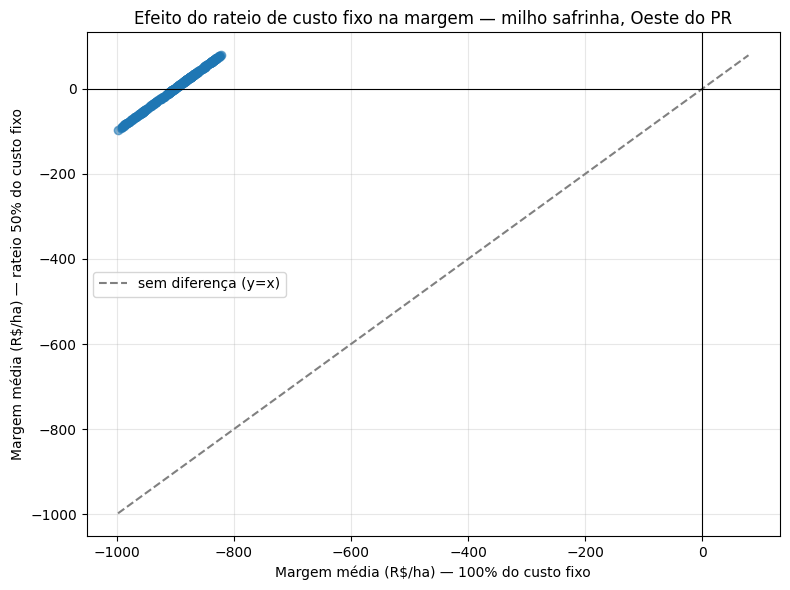

,municipio,data_semeadura,margem_media_rs_ha_100pct,margem_media_rs_ha_rateio50,delta_margem_rs_ha,risco_economico_100pct,risco_economico_rateio50,mudou_classificacao
61,Céu Azul,05/03/,-850.379377,50.717728,901.097105,Mais viável,Mais viável,False
262,São Miguel do Iguaçu,25/02/,-906.932959,-5.835853,901.097105,Viabilidade intermediária,Viabilidade intermediária,False
283,Três Barras do Paraná,05/03/,-839.199999,61.897106,901.097105,Mais viável,Mais viável,False
54,Corbélia,05/02/,-873.494415,27.602691,901.097105,Mais viável,Mais viável,False
204,Pato Bragado,05/02/,-977.068708,-75.971603,901.097105,Menos viável,Menos viável,False
66,Diamante D'Oeste,05/02/,-987.354875,-86.257769,901.097105,Menos viável,Menos viável,False
188,Nova Santa Rosa,15/02/,-937.805444,-36.708339,901.097105,Menos viável,Menos viável,False
51,Catanduvas,15/03/,-832.963765,68.13334,901.097105,Mais viável,Mais viável,False
275,Terra Roxa,25/03/,-924.996452,-23.899347,901.097105,Menos viável,Menos viável,False
59,Corbélia,25/03/,-877.511885,23.585221,901.097105,Viabilidade intermediária,Viabilidade intermediária,False


In [11]:
# Cenário alternativo: rateio de 50% do custo fixo, refletindo que o milho safrinha sucede a soja
# no mesmo ano-agrícola — terra e máquina já estão em parte amortizadas pela cultura principal.
risco_economico_rateio50 = calcular_risco_economico(0.5, "Rateio 50% do custo fixo (sucessão soja→milho)")
risco_economico_rateio50.to_csv("risco_economico_oeste_pr_rateio50.csv", index=False, encoding="utf-8-sig")

comparacao_rateio = risco_economico.merge(
    risco_economico_rateio50,
    on=["municipio", "data_semeadura"],
    suffixes=("_100pct", "_rateio50"),
)
comparacao_rateio["delta_margem_rs_ha"] = (
    comparacao_rateio["margem_media_rs_ha_rateio50"] - comparacao_rateio["margem_media_rs_ha_100pct"]
)
comparacao_rateio["mudou_classificacao"] = (
    comparacao_rateio["risco_economico_100pct"] != comparacao_rateio["risco_economico_rateio50"]
)

n_mudou = comparacao_rateio["mudou_classificacao"].sum()
print(f"Município×data que mudam de classificação de risco econômico com o rateio de 50%: {n_mudou}/{len(comparacao_rateio)}")
print(comparacao_rateio.groupby(["risco_economico_100pct", "risco_economico_rateio50"], observed=True).size())

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(
    comparacao_rateio["margem_media_rs_ha_100pct"],
    comparacao_rateio["margem_media_rs_ha_rateio50"],
    alpha=0.6,
)
lim = [
    min(comparacao_rateio["margem_media_rs_ha_100pct"].min(), comparacao_rateio["margem_media_rs_ha_rateio50"].min()),
    max(comparacao_rateio["margem_media_rs_ha_100pct"].max(), comparacao_rateio["margem_media_rs_ha_rateio50"].max()),
]
ax.plot(lim, lim, linestyle="--", color="gray", label="sem diferença (y=x)")
ax.axhline(0, color="black", linewidth=0.8)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Margem média (R$/ha) — 100% do custo fixo")
ax.set_ylabel("Margem média (R$/ha) — rateio 50% do custo fixo")
ax.set_title("Efeito do rateio de custo fixo na margem — milho safrinha, Oeste do PR")
ax.legend()
plt.tight_layout()
plt.show()

comparacao_rateio.sort_values("delta_margem_rs_ha", ascending=False)[
    ["municipio", "data_semeadura", "margem_media_rs_ha_100pct", "margem_media_rs_ha_rateio50",
     "delta_margem_rs_ha", "risco_economico_100pct", "risco_economico_rateio50", "mudou_classificacao"]
].head(15)

### 6.2 Rateio proporcional aos dias de ocupação da área

A seção 6.1 testou um rateio fixo de 50% como cenário ilustrativo — não encontramos, numa busca por
literatura, uma fonte que estabeleça esse percentual especificamente para a sucessão soja→milho
safrinha. Uma alternativa mais defensável é ratear o custo fixo **proporcionalmente ao tempo que
cada cultura ocupa a área** dentro do ano-agrícola, já que é esse tempo de uso que efetivamente
consome a depreciação de máquinas e o custo de oportunidade da terra (rateio por uso, não por
"metade para cada").

Usando ciclos médios típicos (soja ~160 dias até liberar a área para o safrinha; milho safrinha
~110 dias), o milho responderia por **~110/(160+110) ≈ 41% do custo fixo anual** — mais perto de
40% do que dos 50% testados na seção anterior. Esses números de ciclo são uma aproximação (variam
por cultivar/região/safra) e podem ser ajustados nas constantes `CICLO_SOJA_DIAS` /
`CICLO_MILHO_SAFRINHA_DIAS` abaixo.

In [12]:
CICLO_SOJA_DIAS = 160
CICLO_MILHO_SAFRINHA_DIAS = 110
FATOR_RATEIO_PROPORCIONAL = CICLO_MILHO_SAFRINHA_DIAS / (CICLO_SOJA_DIAS + CICLO_MILHO_SAFRINHA_DIAS)
print(f"Fator de rateio proporcional (dias de ocupação): {FATOR_RATEIO_PROPORCIONAL:.1%}")

risco_economico_proporcional = calcular_risco_economico(
    FATOR_RATEIO_PROPORCIONAL,
    f"Rateio proporcional (~{FATOR_RATEIO_PROPORCIONAL:.0%} do custo fixo, por dias de ocupação)",
)
risco_economico_proporcional.to_csv("risco_economico_oeste_pr_rateio_proporcional.csv", index=False, encoding="utf-8-sig")
risco_economico_proporcional.sort_values("margem_media_rs_ha", ascending=False).head(10)

Fator de rateio proporcional (dias de ocupação): 40.7%

[Rateio proporcional (~41% do custo fixo, por dias de ocupação)] % de combinações (município×data) que cobrem o custo, por ano:
ano
1999    100.0
2000    100.0
2001      0.0
2002    100.0
2003    100.0
2004    100.0
2005     37.0
2006    100.0
2007    100.0
2008    100.0
2009      0.0
2010      0.0
2011    100.0
2012      0.3
2013      0.0
2014      0.0
2015      0.0
2016    100.0
2017      0.0
2018      0.0
2019      0.0
2020    100.0
2021    100.0
2022    100.0
2023    100.0
2024      0.0
Name: cobre_custo, dtype: float64

[Rateio proporcional (~41% do custo fixo, por dias de ocupação)] distribuição de risco_economico:
risco_economico
Menos viável                 100
Viabilidade intermediária    100
Mais viável                  100
Name: count, dtype: int64


,municipio,data_semeadura,n_anos,pct_anos_cobre_custo,margem_media_rs_ha,risco_economico
52,Catanduvas,25/02/,26,57.7,245.348038,Mais viável
112,Ibema,25/02/,26,57.7,244.715244,Mais viável
74,Diamante do Sul,15/02/,26,57.7,242.714193,Mais viável
46,Cascavel,25/02/,26,57.7,242.426999,Mais viável
100,Guaraniaçu,25/02/,26,57.7,242.210832,Mais viável
49,Catanduvas,05/03/,26,57.7,239.427965,Mais viável
34,Campo Bonito,25/02/,26,57.7,238.547769,Mais viável
76,Diamante do Sul,25/02/,26,57.7,238.255797,Mais viável
50,Catanduvas,15/02/,26,57.7,237.893201,Mais viável
98,Guaraniaçu,15/02/,26,57.7,237.430173,Mais viável


            cenario  fator_rateio  margem_media_rs_ha  pct_anos_cobre_custo_media combinacoes_margem_positiva
    100% (original)           1.0              -897.9                         5.8                       0/300
  50% (ilustrativo)           0.5                 3.2                        47.7                     172/300
~41% (proporcional)           0.4               170.1                        55.3                     300/300

Município×data que mudam de classificação de risco econômico no cenário proporcional: 0/300


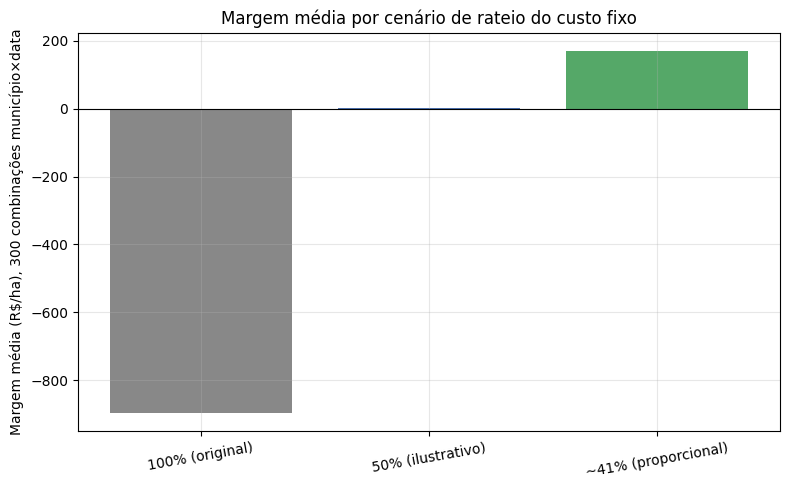

In [13]:
# Resumo consolidado dos 3 cenários de custo fixo — 100% (original), 50% (ilustrativo) e
# ~41% (proporcional aos dias de ocupação, seção 6.2).
CENARIOS = {
    "100% (original)": (1.0, risco_economico),
    "50% (ilustrativo)": (0.5, risco_economico_rateio50),
    f"~{FATOR_RATEIO_PROPORCIONAL:.0%} (proporcional)": (FATOR_RATEIO_PROPORCIONAL, risco_economico_proporcional),
}

resumo_cenarios = pd.DataFrame([
    {
        "cenario": nome,
        "fator_rateio": fator,
        "margem_media_rs_ha": df["margem_media_rs_ha"].mean(),
        "pct_anos_cobre_custo_media": df["pct_anos_cobre_custo"].mean(),
        "combinacoes_margem_positiva": int((df["margem_media_rs_ha"] >= 0).sum()),
    }
    for nome, (fator, df) in CENARIOS.items()
])
resumo_cenarios["combinacoes_margem_positiva"] = (
    resumo_cenarios["combinacoes_margem_positiva"].astype(str) + "/" + str(len(risco_economico))
)
print(resumo_cenarios.round(1).to_string(index=False))

# Comparação de classificação relativa (100% vs. proporcional), mesma lógica da seção 6.1.
comparacao_proporcional = risco_economico.merge(
    risco_economico_proporcional,
    on=["municipio", "data_semeadura"],
    suffixes=("_100pct", "_proporcional"),
)
n_mudou_prop = (
    comparacao_proporcional["risco_economico_100pct"] != comparacao_proporcional["risco_economico_proporcional"]
).sum()
print(f"\nMunicípio×data que mudam de classificação de risco econômico no cenário proporcional: {n_mudou_prop}/{len(comparacao_proporcional)}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(resumo_cenarios["cenario"], resumo_cenarios["margem_media_rs_ha"], color=["#888888", "#4C72B0", "#55A868"])
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Margem média (R$/ha), 300 combinações município×data")
ax.set_title("Margem média por cenário de rateio do custo fixo")
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

## 7. Matriz risco climático × viabilidade econômica — melhor data de semeadura

Cruza os dois eixos por (município, data de semeadura) e usa os dois pra indicar a(s) melhor(es)
data(s) de semeadura de cada município: prioriza **Baixo risco climático + Mais viável**, depois
combinações intermediárias, deixando **Alto risco climático + Menos viável** como pior caso dentro
do cenário simulado (lembrando: "menos viável" é relativo às outras 300 combinações, não significa
que cobre o custo em termos absolutos — ver seção 6).

In [14]:
matriz = isna_cidade_data.merge(
    risco_economico[["municipio", "data_semeadura", "pct_anos_cobre_custo", "margem_media_rs_ha", "risco_economico"]],
    on=["municipio", "data_semeadura"],
)

ORDEM_CLIMA = {"Baixo risco climático": 0, "Médio risco climático": 1, "Alto risco climático": 2}
ORDEM_ECONOMICO = {"Mais viável": 0, "Viabilidade intermediária": 1, "Menos viável": 2}

matriz["score_clima"] = matriz["risco_climatico"].map(ORDEM_CLIMA).astype(int)
matriz["score_economico"] = matriz["risco_economico"].map(ORDEM_ECONOMICO).astype(int)
matriz["score_combinado"] = matriz["score_clima"] + matriz["score_economico"]

matriz.to_csv("matriz_risco_climatico_economico_oeste_pr.csv", index=False, encoding="utf-8-sig")

print("Combinações risco climático × viabilidade econômica relativa:")
print(pd.crosstab(matriz["risco_climatico"], matriz["risco_economico"]))

Combinações risco climático × viabilidade econômica relativa:
risco_economico        Menos viável  Viabilidade intermediária  Mais viável
risco_climatico                                                            
Baixo risco climático            97                         99          100
Médio risco climático             3                          1            0


In [15]:
melhor_data_por_municipio = (
    matriz.sort_values(["municipio", "score_combinado", "isna_medio"], ascending=[True, True, False])
    .groupby("municipio")
    .first()
    .reset_index()[["municipio", "data_semeadura", "risco_climatico", "isna_medio", "risco_economico", "pct_anos_cobre_custo", "margem_media_rs_ha"]]
)
melhor_data_por_municipio.to_csv("melhor_data_semeadura_por_municipio.csv", index=False, encoding="utf-8-sig")
print(melhor_data_por_municipio.shape)
melhor_data_por_municipio.sort_values("isna_medio", ascending=False)

(50, 7)


,municipio,data_semeadura,risco_climatico,isna_medio,risco_economico,pct_anos_cobre_custo,margem_media_rs_ha
12,Diamante do Sul,05/02/,Baixo risco climático,0.786501,Mais viável,3.8,-835.813445
16,Guaraniaçu,05/02/,Baixo risco climático,0.780250,Mais viável,3.8,-840.835385
8,Catanduvas,05/02/,Baixo risco climático,0.778491,Mais viável,3.8,-838.649946
3,Braganey,05/02/,Baixo risco climático,0.775017,Mais viável,3.8,-849.800749
18,Ibema,05/02/,Baixo risco climático,0.774810,Mais viável,3.8,-843.805494
5,Campo Bonito,05/02/,Baixo risco climático,0.774672,Mais viável,3.8,-848.414403
7,Cascavel,05/02/,Baixo risco climático,0.769379,Mais viável,3.8,-851.567845
47,Três Barras do Paraná,05/02/,Baixo risco climático,0.763884,Mais viável,3.8,-871.346753
23,Lindoeste,25/03/,Baixo risco climático,0.762888,Mais viável,7.7,-862.716749
38,Santa Lúcia,25/03/,Baixo risco climático,0.762447,Mais viável,7.7,-863.774756


### Mapa de calor — risco combinado por município × data de semeadura

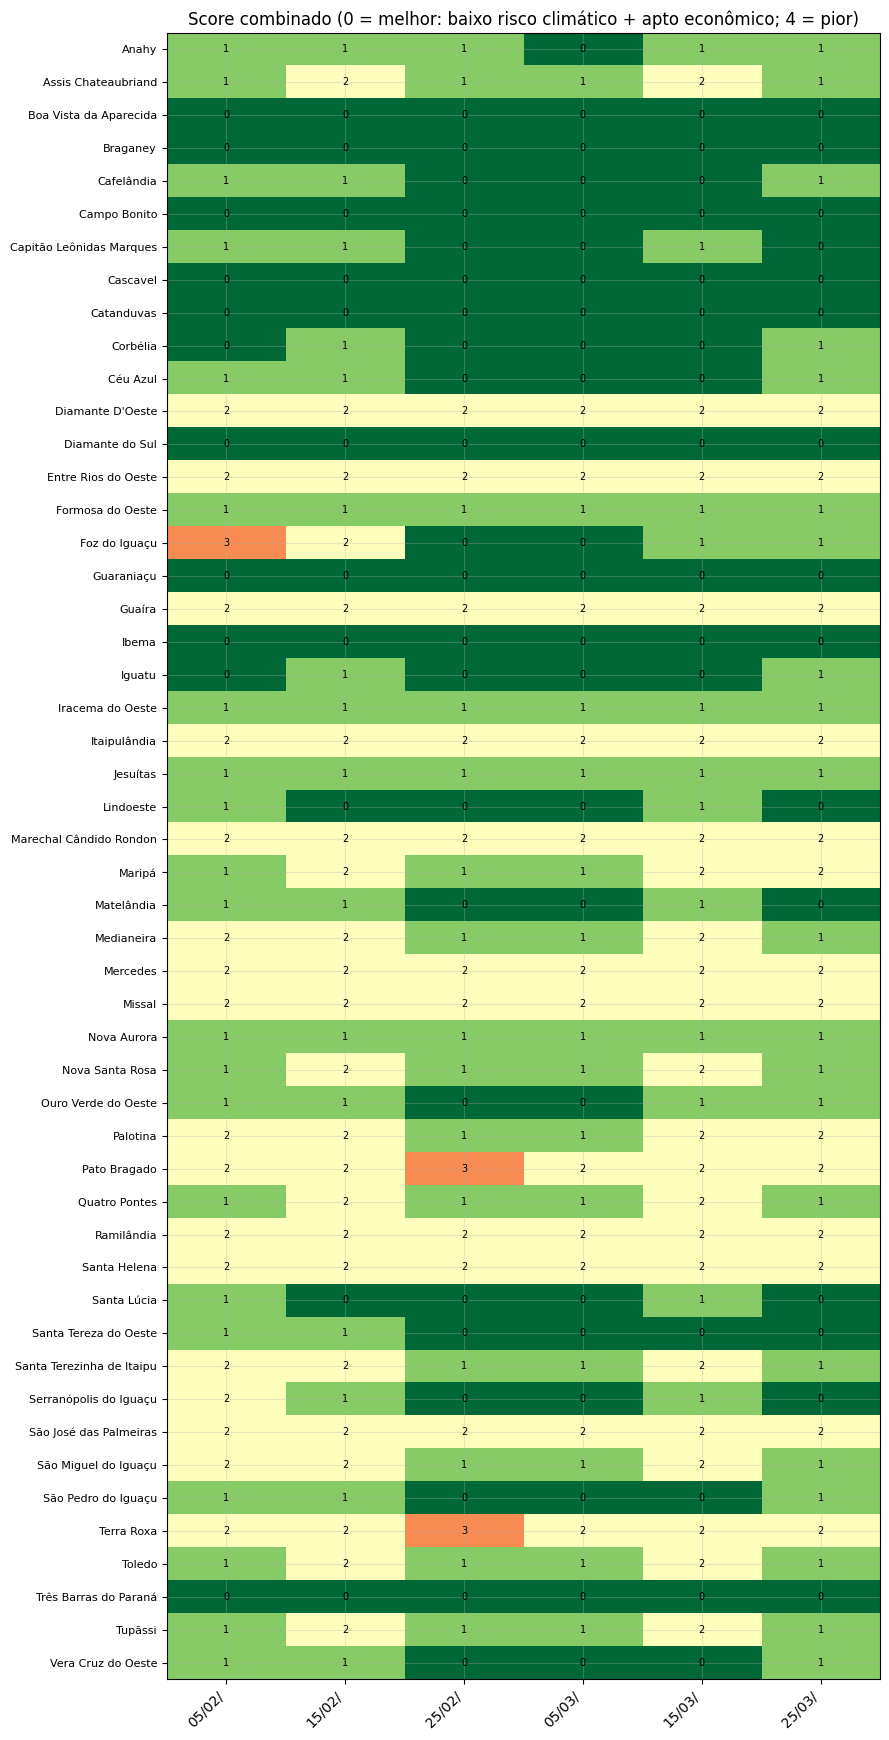

In [16]:
pivot_score = matriz.pivot(index="municipio", columns="data_semeadura", values="score_combinado")[SEM]

fig, ax = plt.subplots(figsize=(9, max(6, 0.35 * len(pivot_score))))
im = ax.imshow(pivot_score, cmap="RdYlGn_r", vmin=0, vmax=4, aspect="auto")
ax.set_xticks(range(len(SEM)))
ax.set_xticklabels(SEM, rotation=45, ha="right")
ax.set_yticks(range(len(pivot_score.index)))
ax.set_yticklabels(pivot_score.index, fontsize=8)
for i in range(pivot_score.shape[0]):
    for j in range(pivot_score.shape[1]):
        v = pivot_score.iloc[i, j]
        if pd.notna(v):
            ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=7)
ax.set_title("Score combinado (0 = melhor: baixo risco climático + apto econômico; 4 = pior)")
plt.tight_layout()
plt.show()

## 8. Limitações a considerar

- **A viabilidade econômica ainda é relativa ao próprio cenário simulado (tercis), não um limiar
  absoluto** — mesmo com a referência DERAL (bem mais compatível em escala), a produtividade de
  equilíbrio média ainda fica um pouco acima do máximo previsto pelo modelo (4.543 kg/ha) — perto
  o bastante pra gerar variação real entre municípios/anos, mas não o bastante pra cruzar pra
  "cobre o custo" em termos absolutos na maioria dos casos.
- **26 anos em comum (1999–2024)** entre a simulação climática e a série DERAL (que só tem dados
  até a safra 2024/25) — 2025 fica de fora da comparação econômica (mas continua no eixo
  climático). Amostra bem mais robusta que a versão anterior (6 anos), mas resultados no limiar
  entre classes ainda são indicativos, não definitivos.
- **Custo fixo e custo variável por kg são médias do próprio período em comum (1999–2024)**, não
  um valor fixo de um único ano — a comparação é ano a ano (a produtividade de cada cenário
  simulado contra o custo/preço reais daquele mesmo ano), preservando a variação histórica real em
  vez de mascará-la numa média.
- **Risco climático (ISNA) e risco econômico são eixos calculados de forma independente por
  desenho** — o econômico usa a série DERAL/preço real ano a ano, o climático usa o balanço hídrico
  simulado; cruzam só na seção 7.
- **Limiares de ISNA (0,65 / 0,50) são ilustrativos**, adaptados da lógica do ZARC, não uma portaria
  oficial replicada — para uso oficial/regulatório, os limiares por cultura precisam ser conferidos
  na fonte (MAPA/Embrapa).